In [1]:
import pandas as pd
import numpy as np
import nltk
import re

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB

import matplotlib.pyplot as plt
import seaborn as sns

nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [2]:
train_df = pd.read_csv("/content/twitter_training.csv")
valid_df = pd.read_csv("/content/twitter_validation.csv")

train_df.columns = [c.strip() for c in train_df.columns]
valid_df.columns = [c.strip() for c in valid_df.columns]

print(train_df.shape)
print(valid_df.shape)

(74682, 4)
(1000, 4)


In [3]:
def clean_tweet(text):
    text = re.sub(r"http\S+|www\S+|https\S+", "", str(text))
    text = re.sub(r"@\w+|[^A-Za-z0-9\s]", "", text)
    text = text.lower().strip()
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words("english"))
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return " ".join(tokens)

label_map = {
    "Positive": 0,
    "Negative": 1,
    "Neutral": 2,
    "Irrelevant": 2
}

train_df["clean_tweet"] = train_df["tweet"].astype(str).apply(clean_tweet)
train_df["label"] = train_df["tweet_sentiment"].map(label_map)

valid_df["clean_tweet"] = valid_df["tweet"].astype(str).apply(clean_tweet)
valid_df["label"] = valid_df["tweet_sentiment"].map(label_map)

print(train_df[["tweet", "clean_tweet", "tweet_sentiment", "label"]].head())

                                               tweet  \
0  im getting on borderlands and i will murder yo...   
1  I am coming to the borders and I will kill you...   
2  im getting on borderlands and i will kill you ...   
3  im coming on borderlands and i will murder you...   
4  im getting on borderlands 2 and i will murder ...   

                  clean_tweet tweet_sentiment  label  
0  getting borderlands murder        Positive      0  
1         coming borders kill        Positive      0  
2    getting borderlands kill        Positive      0  
3   coming borderlands murder        Positive      0  
4  getting borderlands murder        Positive      0  


In [4]:
if len(train_df) > 40000:
    train_sample = train_df.sample(n=40000, random_state=42)
else:
    train_sample = train_df.copy()

vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

X_train = vectorizer.fit_transform(train_sample["clean_tweet"])
y_train = train_sample["label"]

X_valid = vectorizer.transform(valid_df["clean_tweet"])
y_valid = valid_df["label"]

print(X_train.shape)
print(X_valid.shape)

(40000, 10000)
(1000, 10000)


In [5]:
models = {
    "SVM": {
        "estimator": SVC(),
        "params": {
            "C": [10],
            "kernel": ["rbf"]
        }
    },
    "RandomForest": {
        "estimator": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [200],
            "max_depth": [None]
        }
    },
    "MultinomialNB": {
        "estimator": MultinomialNB(),
        "params": {
            "alpha": [0.1]
        }
    },
    "DecisionTree": {
        "estimator": DecisionTreeClassifier(random_state=42),
        "params": {
            "max_depth": [None],
            "min_samples_split": [2]
        }
    }
}

In [6]:
results = {}

for name, cfg in models.items():
    print(f"Running {name}...")
    grid = GridSearchCV(
        estimator=cfg["estimator"],
        param_grid=cfg["params"],
        cv=3,
        scoring="accuracy",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)
    y_pred = grid.predict(X_valid)
    acc = accuracy_score(y_valid, y_pred)

    results[name] = {
        "best_estimator": grid.best_estimator_,
        "best_params": grid.best_params_,
        "accuracy": acc,
        "y_pred": y_pred
    }
    print(f"{name} Accuracy: {acc:.4f}")

Running SVM...
SVM Accuracy: 0.9650
Running RandomForest...
RandomForest Accuracy: 0.9550
Running MultinomialNB...
MultinomialNB Accuracy: 0.8040
Running DecisionTree...
DecisionTree Accuracy: 0.9070


Best Model: SVM
Accuracy: 0.9650


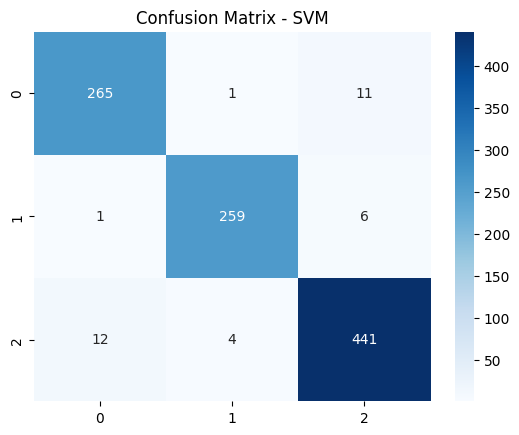

              precision    recall  f1-score   support

           0       0.95      0.96      0.95       277
           1       0.98      0.97      0.98       266
           2       0.96      0.96      0.96       457

    accuracy                           0.96      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.96      0.97      1000



In [7]:
best_model_name = max(results, key=lambda k: results[k]["accuracy"])
best_y_pred = results[best_model_name]["y_pred"]

print(f"Best Model: {best_model_name}")
print(f"Accuracy: {results[best_model_name]['accuracy']:.4f}")

cm = confusion_matrix(y_valid, best_y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

print(classification_report(y_valid, best_y_pred))

In [8]:
summary = pd.DataFrame([
    {
        "Model": name,
        "Accuracy": round(cfg["accuracy"], 4),
        "Best_Params": cfg["best_params"]
    }
    for name, cfg in results.items()
]).sort_values("Accuracy", ascending=False)

print(summary)
summary.to_csv("NLP_Results.csv", index=False)

           Model  Accuracy                                  Best_Params
0            SVM     0.965                   {'C': 10, 'kernel': 'rbf'}
1   RandomForest     0.955     {'max_depth': None, 'n_estimators': 200}
3   DecisionTree     0.907  {'max_depth': None, 'min_samples_split': 2}
2  MultinomialNB     0.804                               {'alpha': 0.1}
